# 07. Statistical Analysis In Numerics
This notebook covers statistical methods and hypothesis testing.

## What You'll Learn

- Descriptive statistics
- Correlation analysis (Pearson, Spearman, Kendall)
- Hypothesis testing (t-test, Mann-Whitney, Kolmogorov-Smirnov)
- Bootstrap resampling
- Outlier detection (Multiple Grubbs-Beck)
- Data transformations (Box-Cox, Yeo-Johnson)
- Histogram and kernel density estimation

## Real-World Applications

Statistical analysis for data exploration, quality control, and inference.

## Set Up

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from System.Collections.Generic import List
from System import Double, Array, Func
import random

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Data.Statistics import Statistics, Correlation, HypothesisTests, GoodnessOfFit, MultipleGrubbsBeckTest, BoxCox, YeoJohnson
from Numerics.Distributions import Normal
from Numerics.Sampling import Bootstrap
from helper_functions import convert_to_dotnet_array

print("✓ Setup complete")

✓ Setup complete


## 1. Descriptive Statistics

Let's analyze streamflow data.

Summary Statistics:
Mean:           913.2860
Std Dev:        1033.2905
Variance:       1067689.1966
Minimum:        49.7488
Maximum:        14504.0789
Skewness:       7.2277
Kurtosis:       83.9785
5th %ile:       209.2429
25th %ile:      394.3886
75th %ile:      1097.2188
95th %ile:      2293.9973


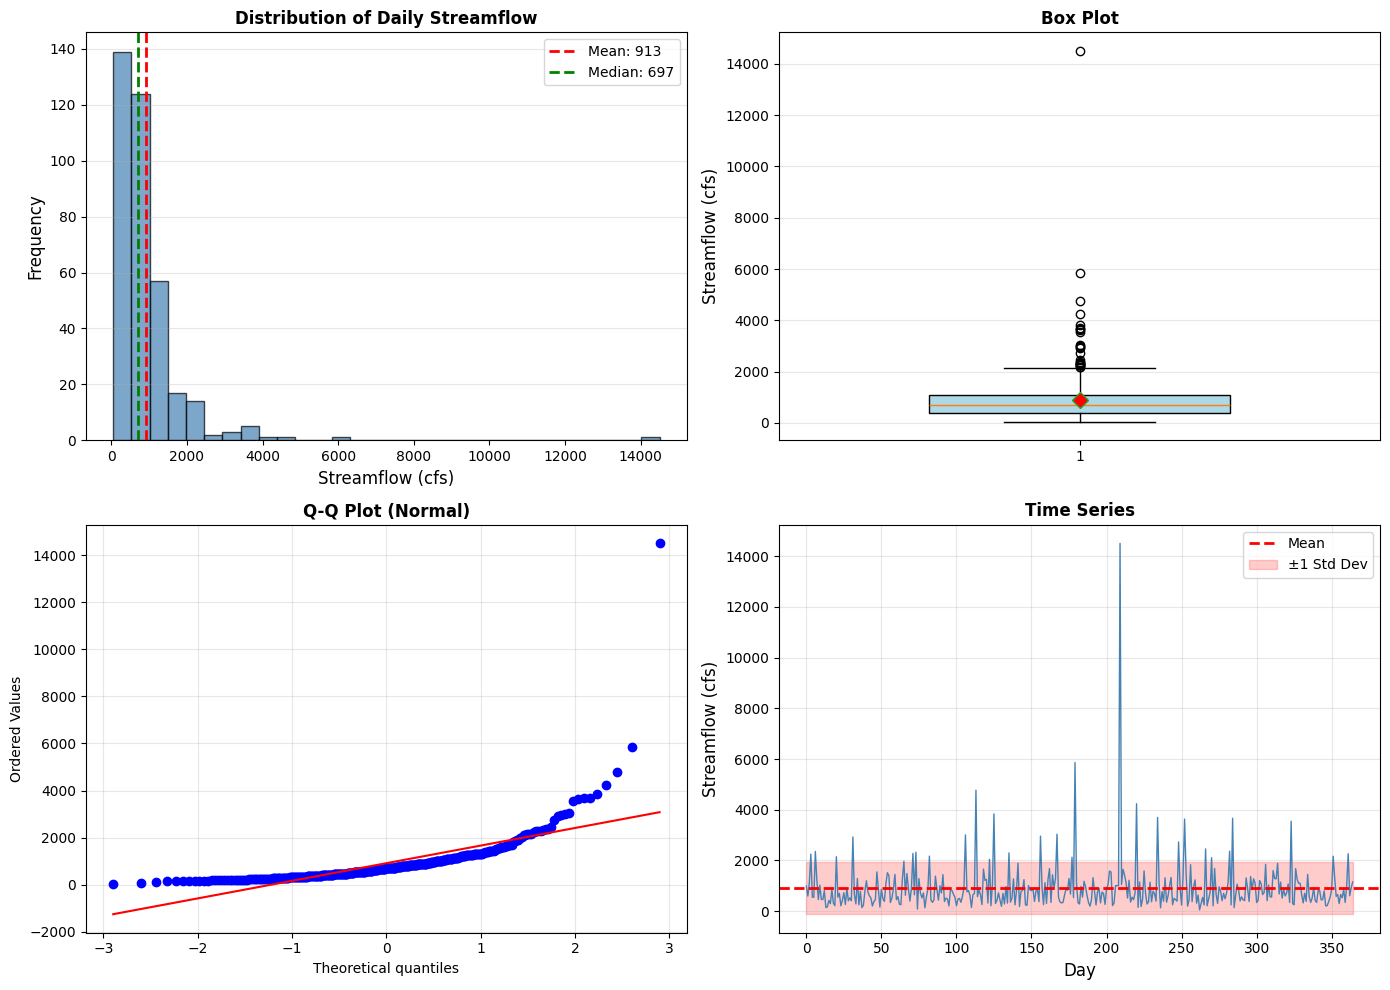

In [7]:
# Generate sample streamflow data (cubic feet per second)
np.random.seed(42)
streamflow = np.random.lognormal(mean=6.5, sigma=0.8, size=365) #COME BACK AND USE NUMERICS LOGNORMAL
streamflow_net = convert_to_dotnet_array(streamflow)

# General statistics
print(f"Summary Statistics:")
print("=" * 60)
print(f"Mean:           {Statistics.Mean(streamflow_net):.4f}")
print(f"Std Dev:        {Statistics.StandardDeviation(streamflow_net):.4f}")
print(f"Variance:       {Statistics.Variance(streamflow_net):.4f}")
print(f"Minimum:        {Statistics.Minimum(streamflow_net):.4f}")
print(f"Maximum:        {Statistics.Maximum(streamflow_net):.4f}")
print(f"Skewness:       {Statistics.Skewness(streamflow_net):.4f}")
print(f"Kurtosis:       {Statistics.Kurtosis(streamflow_net):.4f}")
print(f"5th %ile:       {Statistics.Percentile(streamflow_net, 0.05):.4f}")
print(f"25th %ile:      {Statistics.Percentile(streamflow_net, 0.25):.4f}")
print(f"75th %ile:      {Statistics.Percentile(streamflow_net, 0.75):.4f}")
print(f"95th %ile:      {Statistics.Percentile(streamflow_net, 0.95):.4f}")

# Visualize distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(streamflow, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(np.mean(streamflow), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(streamflow):.0f}')
axes[0, 0].axvline(np.median(streamflow), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: {np.median(streamflow):.0f}')
axes[0, 0].set_xlabel('Streamflow (cfs)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Daily Streamflow', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Box plot
bp = axes[0, 1].boxplot([streamflow], vert=True, patch_artist=True,
                        widths=0.5, showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Streamflow (cfs)', fontsize=12)
axes[0, 1].set_title('Box Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Q-Q plot (Normal)
from scipy import stats
stats.probplot(streamflow, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Time series
axes[1, 1].plot(range(len(streamflow)), streamflow, linewidth=1, color='steelblue')
axes[1, 1].axhline(np.mean(streamflow), color='red', linestyle='--', 
                   linewidth=2, label='Mean')
axes[1, 1].fill_between(range(len(streamflow)),
                        np.mean(streamflow) - np.std(streamflow),
                        np.mean(streamflow) + np.std(streamflow),
                        alpha=0.2, color='red', label='±1 Std Dev')
axes[1, 1].set_xlabel('Day', fontsize=12)
axes[1, 1].set_ylabel('Streamflow (cfs)', fontsize=12)
axes[1, 1].set_title('Time Series', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Correlation Analysis

Measure relationships between variables.


Correlation Analysis:
Pearson correlation:   0.3342  (linear relationship)
Spearman correlation:  0.3631  (monotonic relationship)
Kendall's tau:         0.2448  (rank correlation)


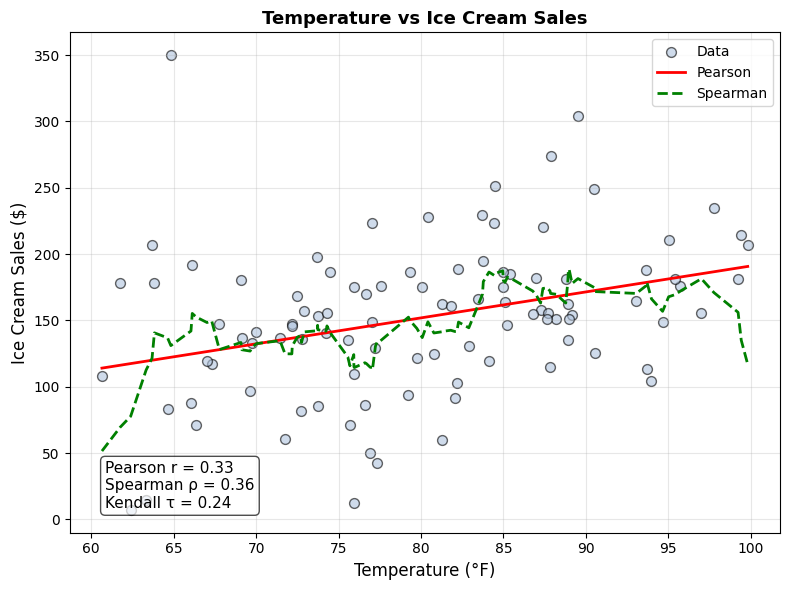

Text(0.5, 1.0, "Kendall's τ = 0.24")

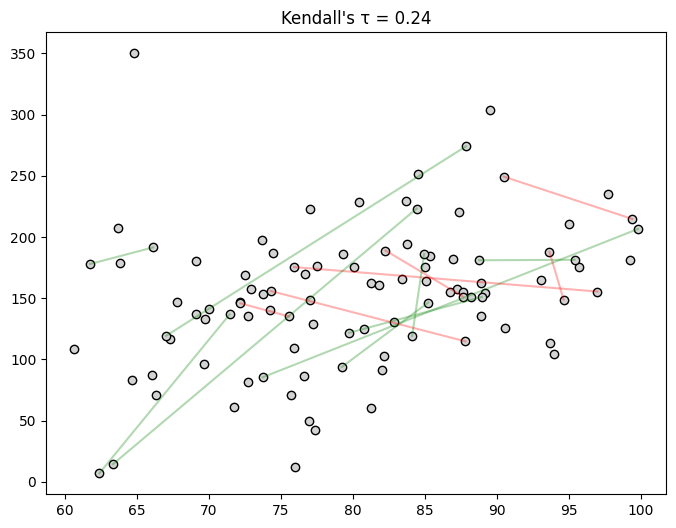

In [ ]:
# Generate correlated data: temperature vs ice cream sales
np.random.seed(123)
n = 100
temperature = np.random.uniform(60, 100, n)
noise = np.random.normal(0, 50, n)
ice_cream_sales = 2.5 * temperature - 50 + noise

# Add some outliers
ice_cream_sales[5] = 50
ice_cream_sales[50] = 350

# Compute correlations using Numerics
temp_net = convert_to_dotnet_array(temperature)
sales_net = convert_to_dotnet_array(ice_cream_sales)

# Pearson correlation (linear)
pearson_corr = Correlation.Pearson(temp_net, sales_net)

# Spearman correlation (rank-based)
spearman_corr = Correlation.Spearman(temp_net, sales_net)

# Kendall Tau correlation (ordinal)
kendall_corr = Correlation.KendallsTau(temp_net, sales_net)

print("\nCorrelation Analysis:")
print("=" * 60)
print(f"Pearson correlation:   {pearson_corr:.4f}  (linear relationship)")
print(f"Spearman correlation:  {spearman_corr:.4f}  (monotonic relationship)")
print(f"Kendall's tau:         {kendall_corr:.4f}  (rank correlation)")

# Visualize correlations
plt.figure(figsize=(8, 6))

plt.text(0.05, 0.05,
         f"Pearson r = {pearson_corr:.2f}\n"
         f"Spearman ρ = {spearman_corr:.2f}\n"
         f"Kendall τ = {kendall_corr:.2f}", # Kendall: annotate as a label only (same monotonic info as Spearman)
         transform=plt.gca().transAxes,
         fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))


# Scatter
plt.scatter(temperature, ice_cream_sales, alpha=0.6, s=50,
            color='lightsteelblue', edgecolor='black', label='Data')

# 1) Pearson: linear fit
z = np.polyfit(temperature, ice_cream_sales, 1)
p = np.poly1d(z)
x_line = np.linspace(temperature.min(), temperature.max(), 200)
plt.plot(x_line, p(x_line), 'r-', linewidth=2,
         label=f'Pearson')

# 2) Spearman: monotonic smooth curve (fit in rank space, plot in x-space)
# Sort by temperature
order = np.argsort(temperature)
temp_sorted = temperature[order]
sales_sorted = ice_cream_sales[order]

# Smooth with a lowess/rolling mean style approximation (no extra libs)
window = max(5, len(temp_sorted)//10)
smoothed = np.convolve(sales_sorted, np.ones(window)/window, mode='same')
plt.plot(temp_sorted, smoothed, color='green', linewidth=2,
         linestyle='--', label=f"Spearman")

plt.xlabel('Temperature (°F)', fontsize=12)
plt.ylabel('Ice Cream Sales ($)', fontsize=12)
plt.title('Temperature vs Ice Cream Sales', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
points = list(zip(temperature, ice_cream_sales))
pairs = random.sample(list(enumerate(points)), 30)  # random subset

for (i, (x1, y1)), (j, (x2, y2)) in zip(pairs[::2], pairs[1::2]):
    concordant = (x1 - x2) * (y1 - y2) > 0
    color = 'green' if concordant else 'red'
    plt.plot([x1, x2], [y1, y2], color=color, alpha=0.3)

plt.scatter(temperature, ice_cream_sales, color='lightgray', edgecolor='black')
plt.title(f"Kendall's τ = {kendall_corr:.2f}")



## 3. Hypothesis Testing: t-test

Compare means of two groups.


Two-Sample t-Test:
Control mean:      101.90
Treatment mean:    112.44
P-value:           0.0001

Conclusion at α=0.05:
✓ Reject null hypothesis - significant difference between groups


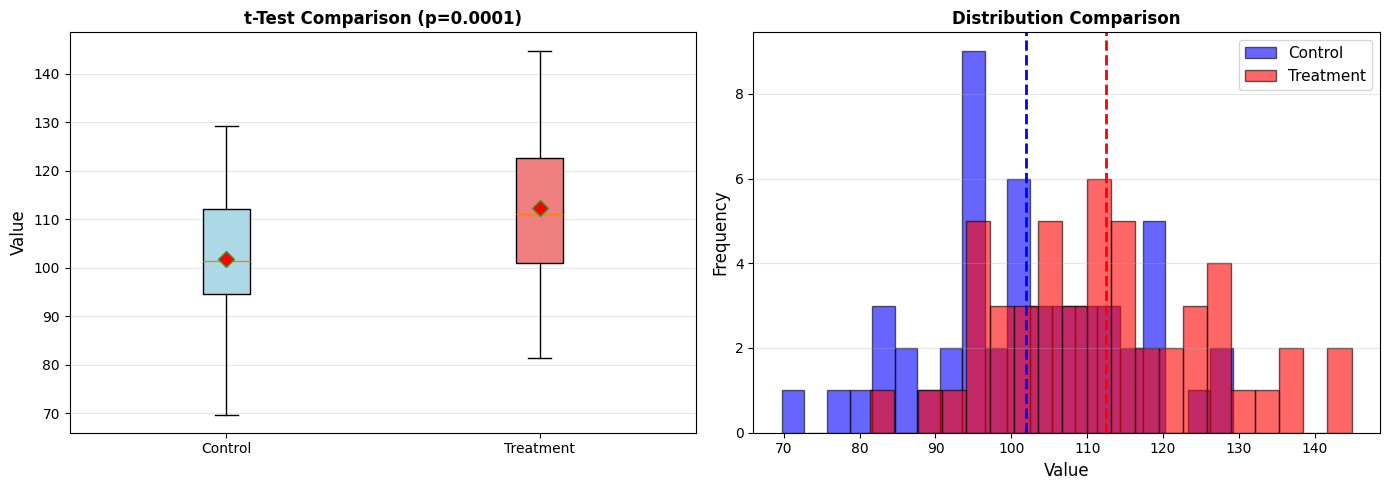

In [29]:
# Two treatment groups
np.random.seed(456)
control_group = np.random.normal(100, 15, 50)
treatment_group = np.random.normal(110, 15, 50)

control_net = convert_to_dotnet_array(control_group)
treatment_net = convert_to_dotnet_array(treatment_group)

# Perform t-test using Numerics
pval = HypothesisTests.PairedTtest(control_net, treatment_net) # returns the 2-sided p-value

print("\nTwo-Sample t-Test:")
print("=" * 60)
print(f"Control mean:      {np.mean(control_group):.2f}")
print(f"Treatment mean:    {np.mean(treatment_group):.2f}")
print(f"P-value:           {pval:.4f}")
print(f"\nConclusion at α=0.05:")
if pval < 0.05:
    print("✓ Reject null hypothesis - significant difference between groups")
else:
    print("✗ Fail to reject null hypothesis - no significant difference")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots
bp = axes[0].boxplot([control_group, treatment_group], 
                      tick_labels=['Control', 'Treatment'],
                      patch_artist=True, showmeans=True,
                      meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title(f't-Test Comparison (p={pval:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Overlapping histograms
axes[1].hist(control_group, bins=20, alpha=0.6, label='Control', 
            color='blue', edgecolor='black')
axes[1].hist(treatment_group, bins=20, alpha=0.6, label='Treatment', 
            color='red', edgecolor='black')
axes[1].axvline(np.mean(control_group), color='blue', linestyle='--', linewidth=2)
axes[1].axvline(np.mean(treatment_group), color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Non-Parametric Test: Mann-Whitney U

For non-normal data or when assumptions are violated.


Mann-Whitney U Test (Non-Parametric):
Group A median:    15.75
Group B median:    18.91
P-value:           0.2366

Conclusion at α=0.05:
✗ No significant difference in distributions


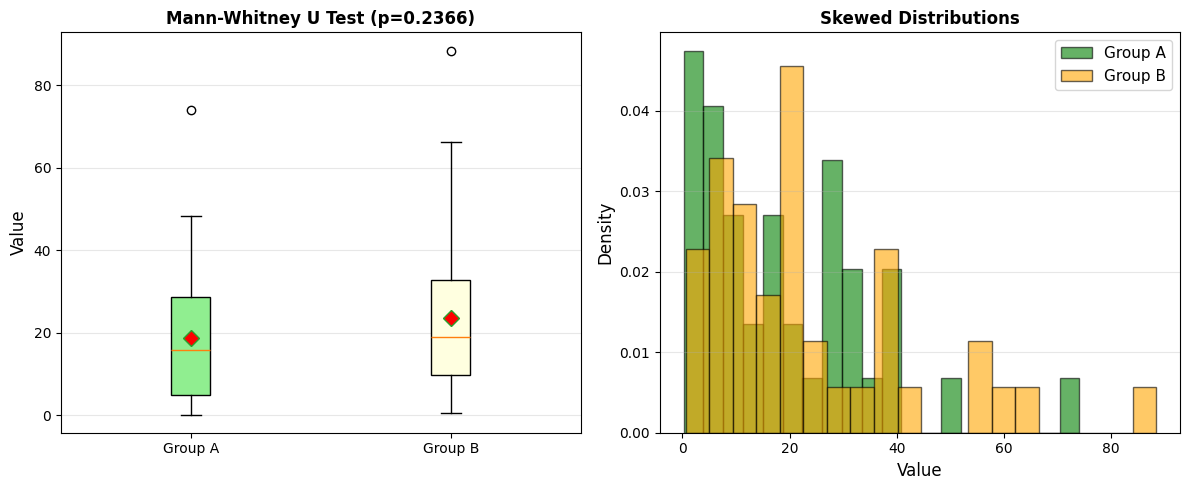

In [31]:
# Non-normal data (skewed)
np.random.seed(789)
group_a = np.random.exponential(scale=20, size=40)
group_b = np.random.exponential(scale=25, size=40)

group_a_net = convert_to_dotnet_array(group_a)
group_b_net = convert_to_dotnet_array(group_b)

# Mann-Whitney U test
pval = HypothesisTests.MannWhitneyTest(group_a_net, group_b_net) # Returns the p-value of test stat

print("\nMann-Whitney U Test (Non-Parametric):")
print("=" * 60)
print(f"Group A median:    {np.median(group_a):.2f}")
print(f"Group B median:    {np.median(group_b):.2f}")
print(f"P-value:           {pval:.4f}")
print(f"\nConclusion at α=0.05:")
if pval < 0.05:
    print("✓ Significant difference in distributions")
else:
    print("✗ No significant difference in distributions")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bp = plt.boxplot([group_a, group_b], tick_labels=['Group A', 'Group B'],
                  patch_artist=True, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightyellow')
plt.ylabel('Value', fontsize=12)
plt.title(f'Mann-Whitney U Test (p={pval:.4f})', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.hist(group_a, bins=20, alpha=0.6, label='Group A', 
        color='green', edgecolor='black', density=True)
plt.hist(group_b, bins=20, alpha=0.6, label='Group B', 
        color='orange', edgecolor='black', density=True)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Skewed Distributions', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Goodness-of-Fit: Kolmogorov-Smirnov Test

Test if data follows a specific distribution.

In [ ]:
# Numerics does not currently provide a direct method for KS p-value calculation,
# so we implement it here based on the asymptotic formula.
def ks_pvalue_one_sample(d, n, tol=1e-8, k_max=1000):
    """
    Two-sided one-sample KS p-value for statistic d and sample size n.
    """
    if n <= 0:
        raise ValueError("n must be positive")

    # Transformation for better approximation
    lam = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * d

    # Series expansion
    s = 0.0
    for k in range(1, k_max+1):
        term = (-1)**(k-1) * np.exp(-2 * (k**2) * (lam**2))
        s += term
        if abs(term) < tol:
            break
    p = 2 * s
    # Numerical safety
    p = min(max(p, 0.0), 1.0)
    return p


Kolmogorov-Smirnov Goodness-of-Fit Test:
Hypothesized: Normal(μ=50, σ=10)
Sample mean:  51.66
Sample std:   10.39

KS statistic: 0.9966
P-value:      0.0000

Conclusion at α=0.05:
✗ Data does not fit Normal(50, 10)


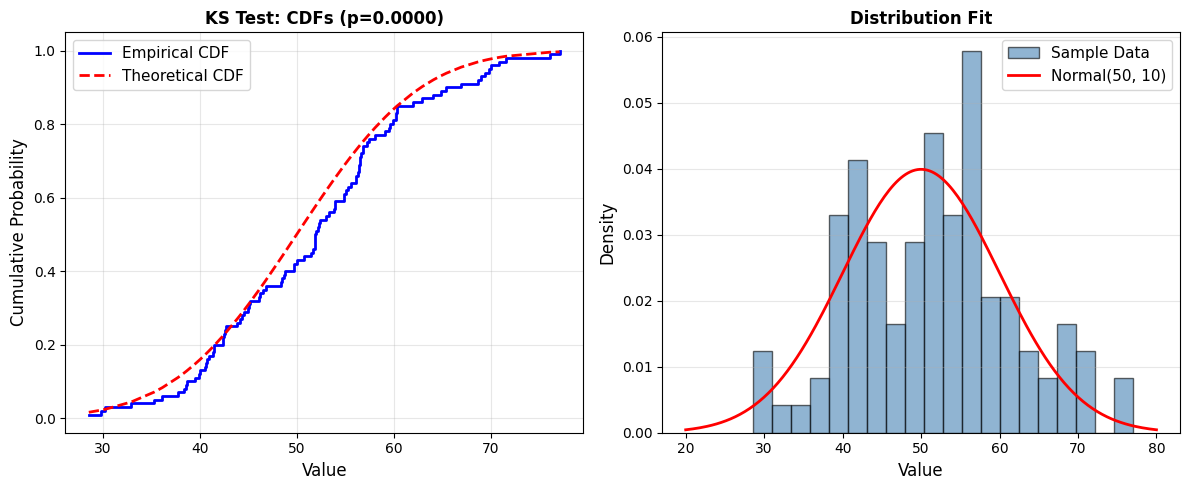

In [38]:
# Generate data
np.random.seed(101)
sample_data = np.random.normal(50, 10, 100)
sample_net = convert_to_dotnet_array(sample_data)

# Hypothesized distribution
hypothesized_dist = Normal(50, 10)

# KS test
ks_test = GoodnessOfFit.KolmogorovSmirnov(sample_net, hypothesized_dist) # Returns test statistic
pval = ks_pvalue_one_sample(ks_test, len(sample_data))

print("\nKolmogorov-Smirnov Goodness-of-Fit Test:")
print("=" * 60)
print(f"Hypothesized: Normal(μ=50, σ=10)")
print(f"Sample mean:  {np.mean(sample_data):.2f}")
print(f"Sample std:   {np.std(sample_data, ddof=1):.2f}")
print(f"\nKS statistic: {ks_test:.4f}")
print(f"P-value:      {pval:.4f}")
print(f"\nConclusion at α=0.05:")
if pval < 0.05:
    print("✗ Data does not fit Normal(50, 10)")
else:
    print("✓ Data is consistent with Normal(50, 10)")
    

# Empirical vs Theoretical CDF
sorted_data = np.sort(sample_data)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = [hypothesized_dist.CDF(x) for x in sorted_data]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.step(sorted_data, empirical_cdf, where='post', linewidth=2, 
        label='Empirical CDF', color='blue')
plt.plot(sorted_data, theoretical_cdf, linewidth=2, 
        label='Theoretical CDF', color='red', linestyle='--')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title(f'KS Test: CDFs (p={pval:.4f})', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(sample_data, bins=20, density=True, alpha=0.6, 
        color='steelblue', edgecolor='black', label='Sample Data')
x_range = np.linspace(20, 80, 200)
pdf = [hypothesized_dist.PDF(x) for x in x_range]
plt.plot(x_range, pdf, 'r-', linewidth=2, label='Normal(50, 10)')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution Fit', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Bootstrap Resampling

Estimate sampling distribution without parametric assumptions.

The Numerics Bootstrap class requires three delegate functions:
1. **ResampleFunction**: How to resample the data
2. **FitFunction**: How to fit the model to resampled data
3. **StatisticFunction**: What statistics to extract from the fit

In [58]:
# from Numerics.Mathematics.Optimization import ParameterSet
# from System import Random

# # Original sample
# np.random.seed(202)
# original_sample = np.random.gamma(shape=2, scale=20, size=50)

# # Convert to .NET array (TData type)
# original_data_net = convert_to_dotnet_array(original_sample)

# # Original fit (just compute mean and std as "parameters")
# original_params = ParameterSet()
# original_params.Values = convert_to_dotnet_array([np.mean(original_sample),
#                                                   np.std(original_sample)])
# # original_params.Values[0] = np.mean(original_sample)
# # original_params.Values[1] = np.std(original_sample, ddof=1)

# # Define the three required functions

# # 1. ResampleFunction: Bootstrap resample the data
# def resample_func(data, params, rng):
#     """Resample with replacement."""
#     n = data.Length
#     resampled = Array.CreateInstance(Double, n)
#     for i in range(n):
#         idx = rng.Next(0, n)  # Random index
#         resampled[i] = data[idx]
#     return resampled

# # 2. FitFunction: Compute statistics from resampled data
# def fit_func(data):
#     """Compute mean and std from resampled data."""
#     data_list = [data[i] for i in range(data.Length)]
#     params = ParameterSet(2)
#     params.Values[0] = np.mean(data_list)  # Mean
#     params.Values[1] = np.std(data_list, ddof=1)  # Std
#     return params

# # 3. StatisticFunction: Extract statistics (in this case, same as parameters)
# def statistic_func(params):
#     """Extract statistics of interest."""
#     stats = Array[Double]([params.Values[0], params.Values[1]])
#     return stats

# # Create Bootstrap instance
# bootstrap = Bootstrap[Array[Double]](original_data_net, original_params)
# bootstrap.ResampleFunction = Func[Array[Double], ParameterSet, Random, Array[Double]](resample_func)
# bootstrap.FitFunction = Func[Array[Double], ParameterSet](fit_func)
# bootstrap.StatisticFunction = Func[ParameterSet, Array[Double]](statistic_func)
# bootstrap.Replicates = 5000
# bootstrap.PRNGSeed = 202

# # Run bootstrap
# bootstrap.Run()

# # Get results
# bootstrap_stats = bootstrap.BootstrapStatistics
# bootstrap_means = [bootstrap_stats[i][0] for i in range(len(bootstrap_stats))]
# bootstrap_stds = [bootstrap_stats[i][1] for i in range(len(bootstrap_stats))]

# # Get confidence intervals
# ci_lower, ci_upper = bootstrap.GetPercentileConfidenceIntervals(0.95)

# print("\nBootstrap Results (5000 replicates):")
# print("=" * 60)
# print(f"Sample mean:        {np.mean(original_sample):.2f}")
# print(f"Bootstrap mean:     {np.mean(bootstrap_means):.2f}")
# print(f"95% CI for mean:    [{ci_lower[0]:.2f}, {ci_upper[0]:.2f}]")
# print(f"\nSample std:         {np.std(original_sample, ddof=1):.2f}")
# print(f"Bootstrap std:      {np.mean(bootstrap_stds):.2f}")
# print(f"95% CI for std:     [{ci_lower[1]:.2f}, {ci_upper[1]:.2f}]")

# # Visualize bootstrap distributions
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].hist(bootstrap_means, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
# axes[0].axvline(np.mean(original_sample), color='red', linestyle='--', 
#                linewidth=2, label='Sample Mean')
# axes[0].axvline(ci_lower[0], color='green', linestyle=':', linewidth=2, label='95% CI')
# axes[0].axvline(ci_upper[0], color='green', linestyle=':', linewidth=2)
# axes[0].set_xlabel('Mean', fontsize=12)
# axes[0].set_ylabel('Frequency', fontsize=12)
# axes[0].set_title('Bootstrap Distribution of Mean', fontsize=12, fontweight='bold')
# axes[0].legend(fontsize=10)
# axes[0].grid(True, alpha=0.3, axis='y')

# axes[1].hist(bootstrap_stds, bins=50, alpha=0.7, color='coral', edgecolor='black')
# axes[1].axvline(np.std(original_sample, ddof=1), color='red', linestyle='--', 
#                linewidth=2, label='Sample Std')
# axes[1].axvline(ci_lower[1], color='green', linestyle=':', linewidth=2, label='95% CI')
# axes[1].axvline(ci_upper[1], color='green', linestyle=':', linewidth=2)
# axes[1].set_xlabel('Standard Deviation', fontsize=12)
# axes[1].set_ylabel('Frequency', fontsize=12)
# axes[1].set_title('Bootstrap Distribution of Std Dev', fontsize=12, fontweight='bold')
# axes[1].legend(fontsize=10)
# axes[1].grid(True, alpha=0.3, axis='y')

# plt.tight_layout()

## 7. Outlier Detection: Multiple Grubbs-Beck Test

Detect multiple outliers using the Numerics implementation.


Outlier Detection: Multiple Grubbs–Beck Low-Outlier Test
Sample size:                 50
Mean:                        98.23
Std Dev:                     21.82

Number of low outliers (MGBT): 2
✓ At least one low outlier detected by Multiple Grubbs–Beck test


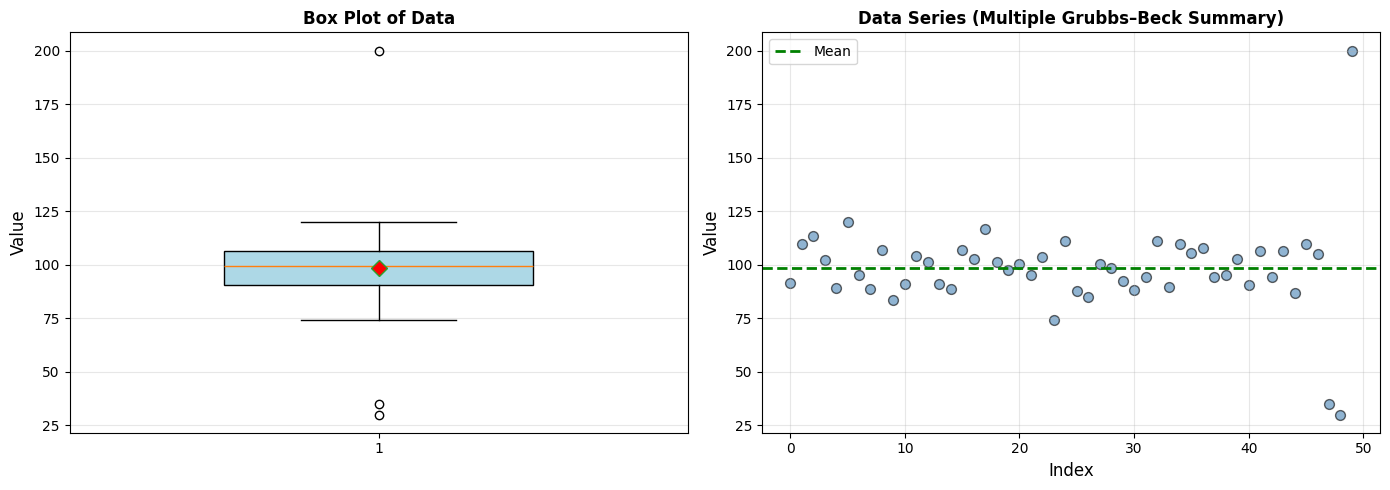

In [67]:
# Data with outliers
np.random.seed(303)
clean_data = np.random.normal(100, 10, 47)
outliers_vals = np.array([35, 30, 200])  # Add obvious outliers
data_with_outliers = np.concatenate([clean_data, outliers_vals])
data_net = convert_to_dotnet_array(data_with_outliers)

# Compute statistics using Numerics
mean_val = Statistics.Mean(data_net)
std_val = Statistics.StandardDeviation(data_net)
#median_val = Statistics.Median(data_net)

# Returns the number of low outliers
grubbs = MultipleGrubbsBeckTest.Function(data_net)


print("\nOutlier Detection: Multiple Grubbs–Beck Low-Outlier Test")
print("=" * 70)
print(f"Sample size:                 {len(data_with_outliers)}")
print(f"Mean:                        {mean_val:.2f}")
print(f"Std Dev:                     {std_val:.2f}")
#print(f"Median:                      {median_val:.2f}")
print(f"\nNumber of low outliers (MGBT): {grubbs}")

if grubbs > 0:
    print("✓ At least one low outlier detected by Multiple Grubbs–Beck test")
else:
    print("✗ No low outliers detected by Multiple Grubbs–Beck test")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of raw data
bp = axes[0].boxplot(
    [data_with_outliers],
    vert=True,
    patch_artist=True,
    widths=0.5,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
)
bp['boxes'][0].set_facecolor('lightblue')

axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Box Plot of Data', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter plot by index with mean line
axes[1].scatter(
    range(len(data_with_outliers)),
    data_with_outliers,
    alpha=0.6,
    s=50,
    color='steelblue',
    edgecolor='black',
)
axes[1].axhline(mean_val, color='green', linestyle='--',
                linewidth=2, label='Mean')
axes[1].set_xlabel('Index', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Data Series (Multiple Grubbs–Beck Summary)', fontsize=12,
                  fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Data Transformations

Box Cox and Yeo-Johnson Transformations

In [ ]:
random.seed(42)
np.random.seed(42)

# Positive-only data (required for Box-Cox)
boxcox_data = np.random.lognormal(mean=1.0, sigma=0.75, size=500).tolist()
boxcox_data_net = convert_to_dotnet_array(boxcox_data)

print("\nBox Cox Data")
print("=" * 60)
print(f"Sample Size:    {len(boxcox_data)}")
print(f"Mean:           {np.mean(boxcox_data):.2f}")
print(f"Std:            {np.std(boxcox_data):.2f}")
print(f"Min:            {np.min(boxcox_data):.2f}")
print(f"Max:            {np.max(boxcox_data):.2f}")

# Fit lambda (MLE)
lambda_bc = BoxCox.FitLambda(boxcox_data_net)
print(f"\nFitted Box-Cox λ (MLE): {lambda_bc: .6f}")

# Forward transform
bc_transformed = BoxCox.Transform(boxcox_data_net, lambda_bc)
print("\nTransformed Data")
print("=" * 60)
print(f"Sample Size:    {len(bc_transformed)}")
print(f"Mean:           {np.mean(bc_transformed):.2f}")
print(f"Std:            {np.std(bc_transformed):.2f}")
print(f"Min:            {np.min(bc_transformed):.2f}")
print(f"Max:            {np.max(bc_transformed):.2f}")

# Inverse transform
bc_inverse = BoxCox.InverseTransform(bc_transformed, lambda_bc)

# Round trip error 
bc_error = np.max(np.abs(boxcox_data - np.asarray(list(bc_inverse)))) # Have to convert bc_inverse to Python list
print(f"\nRound Trip Error: {bc_error:.3e}")



# Mixed-sign data (for Yeo-Johnson)
yeojohnson_data = (
    np.random.normal(loc=0.0, scale=2.0, size=500)
    + np.random.exponential(scale=1.5, size=500) * np.random.choice([-1, 1], 500)
).tolist()
yeojohnson_data_net = convert_to_dotnet_array(yeojohnson_data)

print("\n Yeo-Johnson Data")
print("=" * 60)
print(f"Sample Size:    {len(yeojohnson_data)}")
print(f"Mean:           {np.mean(yeojohnson_data):.2f}")
print(f"Std:            {np.std(yeojohnson_data):.2f}")
print(f"Min:            {np.min(yeojohnson_data):.2f}")
print(f"Max:            {np.max(yeojohnson_data):.2f}")

# Fit lambda (MLE)
lambda_yj = YeoJohnson.FitLambda(yeojohnson_data_net)
print(f"\nFitted Yeo-Johnson λ (MLE): {lambda_yj: .6f}")

# Forward transform
yj_transformed = YeoJohnson.Transform(yeojohnson_data_net, lambda_yj)

print("\nTransformed Data")
print("=" * 60)
print(f"Sample Size:    {len(yj_transformed)}")
print(f"Mean:           {np.mean(yj_transformed):.2f}")
print(f"Std:            {np.std(yj_transformed):.2f}")
print(f"Min:            {np.min(yj_transformed):.2f}")
print(f"Max:            {np.max(yj_transformed):.2f}")

# Inverse transform
yj_inverse = YeoJohnson.InverseTransform(yj_transformed, lambda_yj)

# Round trip error 
yj_error = np.max(np.abs(yeojohnson_data - np.asarray(list(yj_inverse)))) # Have to convert yj_inverse to Python list
print(f"\nRound Trip Error: {yj_error:.3e}")



Box Cox Data
Sample Size:    500
Mean:           3.64
Std:            3.61
Min:            0.24
Max:            48.89

Fitted Box-Cox λ (MLE): -0.075629

Transformed Data
Sample Size:    500
Mean:           0.95
Std:            0.68
Min:            -1.51
Max:            3.37

Round Trip Error: 1.421e-14

 Yeo Johnson Data
Sample Size:    500
Mean:           0.04
Std:            3.07
Min:            -16.46
Max:            12.33

Fitted Yeo-Johnson λ (MLE):  1.005222

Transformed Data
Sample Size:    500
Mean:           0.06
Std:            3.07
Min:            -16.29
Max:            12.45

Round Trip Error: 3.553e-15


## Summary

You've learned:
- Descriptive statistics and data exploration
- Correlation analysis (Pearson, Spearman, Kendall)
- Parametric testing (t-test)
- Non-parametric testing (Mann-Whitney)
- Goodness-of-fit testing (KS test)
- Bootstrap confidence intervals
- Outlier detection (Grubbs' test)
- Data transformations (Box-Cox, Yeo-Johnson)

## Key Takeaways

1. **Start with visualization** - Always plot your data first
2. **Check assumptions** - Use Q-Q plots and normality tests
3. **Choose appropriate tests** - Parametric vs non-parametric
4. **Bootstrap for uncertainty** - Works without strong assumptions
5. **Handle outliers carefully** - Investigate before removing

## Statistical Test Selection Guide

| Situation | Test to Use |
|-----------|-------------|
| Compare 2 means (normal data) | t-test |
| Compare 2 means (non-normal) | Mann-Whitney U |
| Test for normality | KS test, Q-Q plot |
| Outlier detection | Grubbs' test |
| Confidence intervals | Bootstrap |
| Normalize skewed data | Box-Cox transform |
| Mixed signs data | Yeo-Johnson transform |

## Next Steps

- **08_time_series.ipynb** - Temporal data analysis
- **02_distribution_fitting.ipynb** - Fit distributions to data

## Exercise

1. Generate two samples from different distributions
2. Perform both t-test and Mann-Whitney test
3. Create bootstrap confidence intervals
4. Which test is more appropriate? Why?

    INSERT TEST_SINGULAR_VALUE_DECOMP HERE